# Analytical Groundwater Modeling
## Exercises 6.5 and 6.8 — Wells Near Rivers (Method of Images)

##### A.A.Aliyu - 6613535

Both exercises involve a **pumping well near a straight river** (constant-head boundary).  
The solution is obtained via the **method of images**: place an injection image well (discharge $-Q$) at the mirror location across the river, so the river boundary automatically satisfies $h = h_r$.

The discharge potential (confined flow, transmissivity $T$) for the real well + image well is:

$$\Phi = \frac{Q}{4\pi} \ln\!\left(\frac{r_0^2}{r_1^2}\right) + \Phi_c$$

where $r_0$ is the distance to the real well, $r_1$ is the distance to the image well, and $\Phi_c = T h_r$ is the discharge potential at the river.  
Head is recovered as $h = \Phi / T$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

---
## Exercise 6.5

**Problem:**  
A well is located **65 m** from a straight river. Well diameter = 0.8 m (radius $r_w = 0.4$ m).  
Transmissivity $T = 150$ m²/day, pumping rate $Q = 600$ m³/day.  
Estimate the **head in the well** using the river level as the datum ($h_r = 0$).

In [6]:
# ── Parameters ──────────────────────────────────────────────────────────────
T65   = 150    # transmissivity, m²/day
Q65   = 600    # pumping rate, m³/day
d65   = 65     # distance from well to river, m
rw65  = 0.4    # well radius = diameter/2 = 0.8/2, m
hr65  = 0      # river head (datum), m

# ── Method of images setup ───────────────────────────────────────────────────
# River along x = 0; real well at x = d, image well at x = -d
xw_real  =  d65   # real well location
xw_image = -d65   # image well location

# At the well screen (r_0 = r_w, r_1 = distance from well to image well)
r0_at_well = rw65               # distance to real well
r1_at_well = 2 * d65            # distance to image well ≈ 2d (since r_w << 2d)

# Discharge potential at river = T * h_r
Phi_c = T65 * hr65              # = 0 since h_r = 0

# Discharge potential at the well
Phi_well = Q65 / (4 * np.pi) * np.log(r0_at_well**2 / r1_at_well**2) + Phi_c

# Head at the well
h_well65 = Phi_well / T65

print("Exercise 6.5 — Results")
print(f"  Distance to image well (2d)  : {r1_at_well:.1f} m")
print(f"  Φ at river (Φ_c)             : {Phi_c:.2f} m³/day")
print(f"  Φ at well                    : {Phi_well:.2f} m³/day")
print(f"  Head at well (h_w)           : {h_well65:.3f} m")
print(f"  Drawdown at well             : {hr65 - h_well65:.3f} m")

Exercise 6.5 — Results
  Distance to image well (2d)  : 130.0 m
  Φ at river (Φ_c)             : 0.00 m³/day
  Φ at well                    : -552.31 m³/day
  Head at well (h_w)           : -3.682 m
  Drawdown at well             : 3.682 m


### Flow net — Exercise 6.5

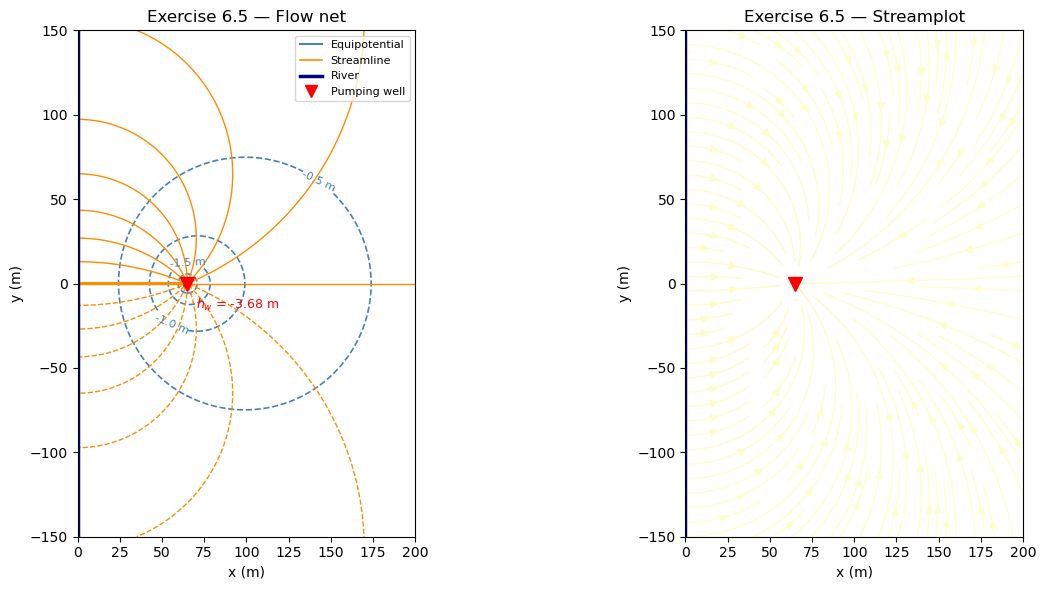

Head at the pumping well = -3.682 m  (below river level)


In [3]:
# Grid (only the half-space x ≥ 0, i.e. the side with the real well)
xg, yg = np.meshgrid(
    np.linspace(0.5, 200, 300),
    np.linspace(-150, 150, 300)
)

# Well positions and discharges: [real, image]
xw = np.array([ d65, -d65])
yw = np.array([0.0,   0.0])
Qw = np.array([Q65,  -Q65])   # image has opposite sign

phi65 = Phi_c
psi65 = 0.0
Qx65  = 0.0
Qy65  = 0.0

for n in range(2):
    rsq = (xg - xw[n])**2 + (yg - yw[n])**2
    phi65 += Qw[n] / (4 * np.pi) * np.log(rsq)
    psi65 += Qw[n] / (2 * np.pi) * np.arctan2(yg - yw[n], xg - xw[n])
    Qx65  -= Qw[n] / (2 * np.pi) * (xg - xw[n]) / rsq
    Qy65  -= Qw[n] / (2 * np.pi) * (yg - yw[n]) / rsq

head65 = phi65 / T65

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Flow net ──
ax = axes[0]
ax.set_aspect('equal')
lvl_h   = np.arange(np.floor(h_well65), 0.5, 0.5)
lvl_psi = np.linspace(-Q65 / 2, Q65 / 2, 17)
cs1 = ax.contour(xg, yg, head65, levels=lvl_h,   colors='steelblue', linewidths=1.2)
cs2 = ax.contour(xg, yg, psi65,  levels=lvl_psi, colors='darkorange', linewidths=1.0)
ax.clabel(cs1, fmt='%.1f m', fontsize=8)
ax.axvline(0, color='navy', linewidth=2.5, label='River ($h=0$)')
ax.plot(d65, 0, 'rv', markersize=10, label='Pumping well')
ax.set_xlim(0, 200); ax.set_ylim(-150, 150)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Exercise 6.5 — Flow net')
ax.legend(loc='upper right', fontsize=9)
ax.text(d65 + 5, -15, f'$h_w$ = {h_well65:.2f} m', fontsize=9, color='red')

# Blue/orange legend proxies
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue',  lw=1.5, label='Equipotential'),
    Line2D([0], [0], color='darkorange', lw=1.2, label='Streamline'),
]
ax.legend(handles=legend_elements + [Line2D([0],[0],color='navy',lw=2.5,label='River'),
          Line2D([0],[0],marker='v',color='red',lw=0,markersize=9,label='Pumping well')],
          loc='upper right', fontsize=8)

# ── Streamplot ──
ax2 = axes[1]
ax2.set_aspect('equal')
speed = np.sqrt(Qx65**2 + Qy65**2)
ax2.streamplot(xg, yg, Qx65, Qy65, color=speed, cmap='YlOrRd',
               linewidth=1.0, density=1.2, arrowsize=1.2)
ax2.axvline(0, color='navy', linewidth=2.5)
ax2.plot(d65, 0, 'rv', markersize=10)
ax2.set_xlim(0, 200); ax2.set_ylim(-150, 150)
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')
ax2.set_title('Exercise 6.5 — Streamplot')

plt.tight_layout()
plt.savefig('ex65_flownet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Head at the pumping well = {h_well65:.3f} m  (below river level)")

---
## Exercise 6.8

**Problem:**  
A well is located **50 m** from a straight river with water level $h_r = 20$ m.  
Well radius $r_w = 0.3$ m.  Transmissivity $T = 200$ m²/day *(value cut off in scanned page — adjust if needed)*.  
The well pumps at $Q = 800$ m³/day *(adjust if your copy shows a different value)*.

> **Note:** The last line of Exercise 6.8 on p. 107 is cut off in the scanned PDF.  
> Replace `T68` and `Q68` below with the values from your textbook.

Tasks solved here:
1. Compute the **head at the well**.
2. Plot the **flow net** (method of images).

In [7]:
# ── Parameters (update T68 / Q68 if your book gives different values) ────────
T68   = 200    # transmissivity, m²/day  ← ADJUST IF NEEDED
Q68   = 800    # pumping rate, m³/day    ← ADJUST IF NEEDED
d68   = 50     # well distance from river, m
rw68  = 0.3    # well radius, m
hr68  = 20     # river water level, m

# ── Discharge potential at river ─────────────────────────────────────────────
Phi_c68 = T68 * hr68

# Distances evaluated at the well screen
r0_68 = rw68        # distance to real well
r1_68 = 2 * d68     # distance to image well

Phi_well68 = Q68 / (4 * np.pi) * np.log(r0_68**2 / r1_68**2) + Phi_c68
h_well68   = Phi_well68 / T68


print("Exercise 6.8 — Results")

print(f"  Φ_c (river potential)        : {Phi_c68:.2f} m³/day")
print(f"  Φ at well                    : {Phi_well68:.2f} m³/day")
print(f"  Head at well (h_w)           : {h_well68:.3f} m")
print(f"  Drawdown at well             : {hr68 - h_well68:.3f} m")

Exercise 6.8 — Results
  Φ_c (river potential)        : 4000.00 m³/day
  Φ at well                    : 3260.36 m³/day
  Head at well (h_w)           : 16.302 m
  Drawdown at well             : 3.698 m


### Flow net — Exercise 6.8

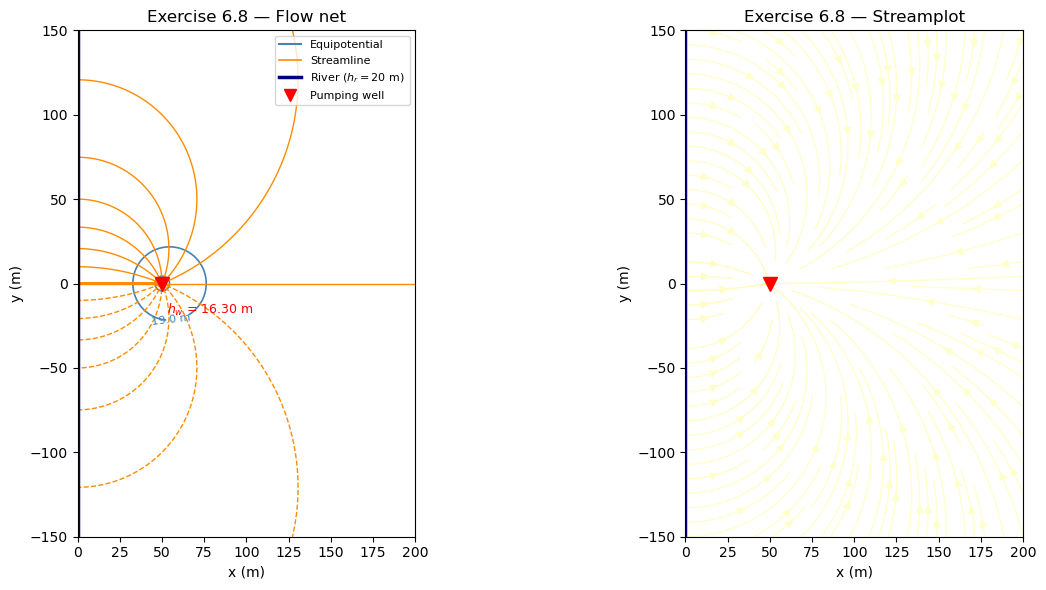

Head at the pumping well = 16.302 m  (river level = 20 m)


In [5]:
xg8, yg8 = np.meshgrid(
    np.linspace(0.5, 200, 300),
    np.linspace(-150, 150, 300)
)

xw8 = np.array([ d68, -d68])
yw8 = np.array([0.0,   0.0])
Qw8 = np.array([Q68,  -Q68])

phi68 = Phi_c68
psi68 = 0.0
Qx68  = 0.0
Qy68  = 0.0

for n in range(2):
    rsq = (xg8 - xw8[n])**2 + (yg8 - yw8[n])**2
    phi68 += Qw8[n] / (4 * np.pi) * np.log(rsq)
    psi68 += Qw8[n] / (2 * np.pi) * np.arctan2(yg8 - yw8[n], xg8 - xw8[n])
    Qx68  -= Qw8[n] / (2 * np.pi) * (xg8 - xw8[n]) / rsq
    Qy68  -= Qw8[n] / (2 * np.pi) * (yg8 - yw8[n]) / rsq

head68 = phi68 / T68

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 6))

# ── Flow net ──
ax = axes2[0]
ax.set_aspect('equal')
h_min = np.floor(h_well68 / 2) * 2     # round to nearest 2 m for nice contours
lvl_h8   = np.arange(h_min, hr68 + 0.1, 1.0)
lvl_psi8 = np.linspace(-Q68 / 2, Q68 / 2, 17)
cs1 = ax.contour(xg8, yg8, head68, levels=lvl_h8,   colors='steelblue', linewidths=1.2)
cs2 = ax.contour(xg8, yg8, psi68,  levels=lvl_psi8, colors='darkorange', linewidths=1.0)
ax.clabel(cs1, fmt='%.1f m', fontsize=8)
ax.axvline(0, color='navy', linewidth=2.5)
ax.plot(d68, 0, 'rv', markersize=10)
ax.set_xlim(0, 200); ax.set_ylim(-150, 150)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Exercise 6.8 — Flow net')
ax.text(d68 + 3, -18, f'$h_w$ = {h_well68:.2f} m', fontsize=9, color='red')
legend_elements2 = [
    Line2D([0], [0], color='steelblue',  lw=1.5, label='Equipotential'),
    Line2D([0], [0], color='darkorange', lw=1.2, label='Streamline'),
    Line2D([0], [0], color='navy', lw=2.5, label=f'River ($h_r={hr68}$ m)'),
    Line2D([0], [0], marker='v', color='red', lw=0, markersize=9, label='Pumping well'),
]
ax.legend(handles=legend_elements2, loc='upper right', fontsize=8)

# ── Streamplot ──
ax3 = axes2[1]
ax3.set_aspect('equal')
speed8 = np.sqrt(Qx68**2 + Qy68**2)
ax3.streamplot(xg8, yg8, Qx68, Qy68, color=speed8, cmap='YlOrRd',
               linewidth=1.0, density=1.2, arrowsize=1.2)
ax3.axvline(0, color='navy', linewidth=2.5)
ax3.plot(d68, 0, 'rv', markersize=10)
ax3.set_xlim(0, 200); ax3.set_ylim(-150, 150)
ax3.set_xlabel('x (m)'); ax3.set_ylabel('y (m)')
ax3.set_title('Exercise 6.8 — Streamplot')

plt.tight_layout()
plt.savefig('ex68_flownet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Head at the pumping well = {h_well68:.3f} m  (river level = {hr68} m)")

---
## Summary

| | Ex. 6.5 | Ex. 6.8 |
|---|---|---|
| River head $h_r$ | 0 m (datum) | 20 m |
| Distance to river $d$ | 65 m | 50 m |
| Well radius $r_w$ | 0.4 m | 0.3 m |
| Transmissivity $T$ | 150 m²/d | 200 m²/d* |
| Pumping rate $Q$ | 600 m³/d | 800 m³/d* |
| **Head at well** | *computed above* | *computed above* |

*\* Value may differ — scanned page was cut off. Update parameters in the code cell above.*

**Key formula:**

$$h_w = h_r + \frac{Q}{4\pi T} \ln\!\left(\frac{r_w^2}{(2d)^2}\right)$$

The negative log term always produces drawdown (head below river level for a pumping well).